# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
import scipy.io

B_scan_path = "/Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw"
M_scan_1_path = "/Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/MScan1.raw"
M_scan_40_path = "/Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/MScan40.raw"
L2K_path = "/Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/L2K.mat"

import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["cmr10"],        # Matplotlib's internal name for Computer Modern
    "mathtext.fontset": "cm",       # Matching math font
    "axes.formatter.use_mathtext": True, # Crucial to fix missing minus signs on axes
    "font.size": 11,
    "figure.figsize": (5.8, 4.0)
})


# File loading functions

In [3]:
def load_raw(filepath: str, n_bg: int, N: int = 2048):
    """
    Load a little-endian uint16 .raw file and split into backgrounds / data.

    The file is a flat sequence of A-scans, each N=2048 samples long,
    stored sample-by-sample (i.e. column-major when viewed as a 2-D matrix).

    Returns
    -------
    bg   : ndarray float64, shape (N, n_bg)  – background scans
    data : ndarray float64, shape (N, M)     – data A-scans
    """
    raw = np.fromfile(filepath, dtype="<u2").astype(np.float64)

    # Each A-scan = N consecutive entries  →  reshape column-major ('F' order)
    # so column j = samples of the j-th A-scan
    # -1 makes the second dimension whatever it needs to be to fit all data
    raw2d = raw.reshape(N, -1, order="F")   # (N, n_bg + M)

    bg   = raw2d[:, :n_bg]
    data = raw2d[:, n_bg:]
    return bg, data


def load_L2K(filepath: str) -> np.ndarray:
    """
    Load the 2048×2048 lambda-to-k resampling matrix.
    Supports .mat (MATLAB) or .npy files.
    """
    if filepath.endswith(".npy"):
        return np.load(filepath)

    mat = scipy.io.loadmat(filepath)
    # Find the first non-metadata key
    for key, val in mat.items():
        if not key.startswith("_") and isinstance(val, np.ndarray):
            print(f"  L2K loaded from key '{key}', shape {val.shape}")
            return val.astype(np.float64)

    raise ValueError("Could not locate L2K matrix in .mat file")

# Guiding computations
Given the information in the introduction, compute the following:
1. The lateral resolution of the system. What limits the lateral resolution?
2. The axial resolution of the system. What limits the axial resolution?
3. The B-Scan “pixel” aspect ratios. What will the B-Scan’s aspect ratio be, with/without
accounting for the “mirror image” artifact of OCT.

In [4]:
# ── Given system parameters 
lambda_0    = 1300         # center wavelength (nm)
dlambda     = 100           # source bandwidth (nm)
N           = 2048          # CCD pixels per A-scan
NA          = 0.055         # numerical aperture of objective lens
n           = 1             # refractive index (air)
bscan_width = 1.0           # physical width of B-scan (mm)

N_BG_BSCAN  = 175           # background columns in B-scan file
N_BG_MSCAN  = 320           # background columns in M-scan files
FS          = 97656.25      # M-scan sampling rate (Hz)
DZ          = 3.6e-6        # axial pixel size (m)
DZ_MM       = DZ * 1e3      # axial pixel size (mm)
DZ_UM       = DZ * 1e6      # axial pixel size (µm)

# ── Read M from the B-scan file 
bg_bscan, data_bscan = load_raw(B_scan_path, N_BG_BSCAN, N)
M    = data_bscan.shape[1]          # number of A-scans in the B-scan
dx_mm = bscan_width / M             # lateral pixel size (mm)
dx_um = dx_mm * 1e3                 # lateral pixel size (µm)

# ── 1. Lateral resolution ─────────────────────────────────────────────────────
dx_res_um = 0.37 * lambda_0 / NA / 1e3     # convert nm → µm
print(f"Lateral resolution  δx = {dx_res_um:.2f} µm  (limited by objective NA)")

# ── 2. Axial resolution ───────────────────────────────────────────────────────
dz_res_um = (2 * np.log(2) / (np.pi * n)) * (lambda_0**2 / dlambda) / 1e3
print(f"Axial resolution    δz = {dz_res_um:.2f} µm  (coherence-limited)")

# ── 3. B-scan pixel sizes and aspect ratios ───────────────────────────────────
depth_full_mm = N       * DZ_MM     # total depth, mirror included
depth_half_mm = (N//2)  * DZ_MM     # depth after mirror crop

pixel_ar = dx_um / DZ_UM            # lateral / axial pixel size ratio

print(f"\nB-scan data:")
print(f"  M = {M} A-scans  →  lateral pixel size dx = {dx_um:.2f} µm")
print(f"  Pixel aspect ratio  dx/dz = {dx_um:.2f}/{DZ_UM:.1f} = {pixel_ar:.4f}")
print(f"  (each pixel is {1/pixel_ar:.1f}× taller than wide)")

print(f"\nImage aspect ratio (width : depth):")
print(f"  Without mirror crop: {bscan_width:.1f} mm : {depth_full_mm:.2f} mm  "
      f"≈  1 : {depth_full_mm/bscan_width:.1f}")
print(f"  With mirror crop:    {bscan_width:.1f} mm : {depth_half_mm:.2f} mm  "
      f"≈  1 : {depth_half_mm/bscan_width:.1f}")

Lateral resolution  δx = 8.75 µm  (limited by objective NA)
Axial resolution    δz = 7.46 µm  (coherence-limited)

B-scan data:
  M = 10000 A-scans  →  lateral pixel size dx = 0.10 µm
  Pixel aspect ratio  dx/dz = 0.10/3.6 = 0.0278
  (each pixel is 36.0× taller than wide)

Image aspect ratio (width : depth):
  Without mirror crop: 1.0 mm : 7.37 mm  ≈  1 : 7.4
  With mirror crop:    1.0 mm : 3.69 mm  ≈  1 : 3.7


# A-Scans

## A-scan computing function

In [6]:
def compute_ascans(
    filepath: str,
    n_bg: int,
    L2K: np.ndarray,
    poly_order: int = 8,
    N: int = 2048,
    do_background_sub: bool = True,
    do_deconv: bool = True,
    verbose: bool = True,
):
    """
    Process a raw SD-OCT file into complex A-scans (no for-loops).

    Parameters
    ----------
    filepath        : path to .raw file
    n_bg            : number of background columns in the file
    L2K             : (N, N) lambda-to-k resampling matrix
    poly_order      : degree of polynomial fit to the source spectrum
    do_background_sub : if False, skip background subtraction
    do_deconv       : if False, skip deconvolution step
    verbose         : print timing for each step

    Returns
    -------
    ascans  : complex ndarray, shape (N, M)  – complex depth-domain A-scans
    timings : dict of step-name → elapsed seconds
    """
    timings = {}

    def tick(label, t_start):
        dt = time.perf_counter() - t_start
        timings[label] = dt
        if verbose:
            print(f"    {label:<22s}: {dt:.4f} s")
        return time.perf_counter()

    if verbose:
        print(f"\n{'─'*55}")
        print(f"  File : {filepath}")
        print(f"{'─'*55}")

    # Load raw data
    t = time.perf_counter()
    bg, data = load_raw(filepath, n_bg, N)
    t = tick("Load", t)
    M = data.shape[1]
    if verbose:
        print(f"    → {M} data A-scans, {n_bg} backgrounds")

    # Average background 
    # mean_bg shape: (N, 1) – broadcast-ready
    mean_bg = bg.mean(axis=1, keepdims=True)
    t = tick("Average background", t)

    # Background subtraction 
    # Removes DC / fixed-pattern noise introduced by the reference arm
    if do_background_sub:
        data_bs = data - mean_bg          # (N, M)  – vectorised broadcast
    else:
        data_bs = data.copy()
    t = tick("BG subtraction", t)

    # Polynomial fit to mean_bg (source-spectrum envelope) 
    # We do NOT use this fit for subtraction, only for deconvolution.
    pixels  = np.arange(N, dtype=np.float64)
    coeffs  = np.polyfit(pixels, mean_bg.squeeze(), poly_order)
    poly_func = np.polyval(coeffs, pixels).reshape(-1, 1)   # (N, 1)
    t = tick(f"Poly fit (order {poly_order})", t)

    # Hanning windowing
    window    = np.hanning(N).reshape(-1, 1)        # (N, 1)
    data_win  = data_bs * window                    # (N, M)
    t = tick("Hanning windowing", t)

    # Deconvolution 
    if do_deconv:
        data_deconv = data_win / poly_func          # (N, M)
    else:
        data_deconv = data_win
    t = tick("Deconvolution", t)

    # Lambda to k resampling (L2K matrix multiply) 
    # OCT fringe data is evenly spaced in wavelength λ, but the FFT assumes even spacing in wavenumber k = 2π/λ.  
    # L2K is a pre-computedinterpolation matrix that performs this resampling in one matrix multiplication.
    data_k = L2K @ data_deconv                      # (N, M)
    t = tick("L2K resampling", t)

    # FFT to get complex spatial-domain A-scans
    ascans = np.fft.fft(data_k, axis=0)             # (N, M)
    t = tick("FFT", t)

    total = sum(timings.values())
    if verbose:
        print(f"    {'─'*36}")
        print(f"    {'TOTAL':<22s}: {total:.3f} s\n")

    return ascans, timings

## Plotting functions

In [7]:
def ascan_db(ascan_col: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return (depth_mm, magnitude_dB) for the positive-depth half only."""
    half   = len(ascan_col) // 2
    z_mm   = np.arange(half) * DZ_MM
    mag_db = 20.0 * np.log10(np.abs(ascan_col[:half]) + 1e-12)
    return z_mm, mag_db


def plot_ascans(ascans_dict: dict, cols: list[int], title_prefix: str):
    """
    Plot selected A-scan columns from one or more processed datasets.

    ascans_dict : {label: complex ndarray (N, M)}
    cols        : list of column indices to plot
    """
    n_plots = len(cols) * len(ascans_dict)
    fig, axes = plt.subplots(len(cols), len(ascans_dict),
                             figsize=(6 * len(ascans_dict), 4 * len(cols)),
                             squeeze=False)

    for col_idx, col in enumerate(cols):
        for ds_idx, (label, ascans) in enumerate(ascans_dict.items()):
            ax  = axes[col_idx][ds_idx]
            z, m = ascan_db(ascans[:, col])
            ax.plot(z, m, linewidth=0.8)
            ax.set_xlabel("Depth (mm)")
            ax.set_ylabel("Magnitude (dB)")
            ax.set_title(f"{title_prefix} – {label}\nA-scan #{col}")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def plot_bg_vs_fit(mean_bg: np.ndarray, poly_func: np.ndarray, poly_order: int):
    """Visualise the polynomial fit quality against the raw mean background."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mean_bg.squeeze(), label="Mean background", alpha=0.7)
    ax.plot(poly_func.squeeze(), label=f"Poly fit (order {poly_order})",
            linewidth=2, color="tomato")
    ax.set_xlabel("Pixel index")
    ax.set_ylabel("ADC counts")
    ax.set_title("Mean background vs polynomial fit (source spectrum envelope)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_pipeline_comparison(ascans_full, ascans_no_deconv, ascans_raw, col: int):
    """
    Compare three processing stages for a single A-scan column:
      a) Full pipeline (BG sub + window + deconv)
      b) BG subtraction + window, no deconvolution
      c) No BG subtraction, no deconvolution
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    configs = [
        (ascans_full,      "Full pipeline\n(BG sub + deconv)"),
        (ascans_no_deconv, "BG sub only\n(no deconv)"),
        (ascans_raw,       "No BG sub\nNo deconv"),
    ]
    for ax, (ascans, label) in zip(axes, configs):
        z, m = ascan_db(ascans[:, col])
        ax.plot(z, m, linewidth=0.8)
        ax.set_xlabel("Depth (mm)")
        ax.set_ylabel("Magnitude (dB)")
        ax.set_title(label)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Processing pipeline comparison: A-scan #{col}", fontsize=13)
    plt.tight_layout()
    return fig

## Test polynomial fits for background
Use 16 order

In [8]:
pixels       = np.arange(N, dtype=np.float64)

bg_bscan, data_bscan = load_raw(B_scan_path, N_BG_BSCAN, N)
mean_bg_b    = bg_bscan.mean(axis=1, keepdims=True)

bg_mscan_1, data_mscan_1 = load_raw(M_scan_1_path, N_BG_MSCAN, N)
mean_bg_m1   = bg_mscan_1.mean(axis=1, keepdims=True)

bg_mscan_40, data_mscan_40 = load_raw(M_scan_40_path, N_BG_MSCAN, N)
mean_bg_m40   = bg_mscan_40.mean(axis=1, keepdims=True)

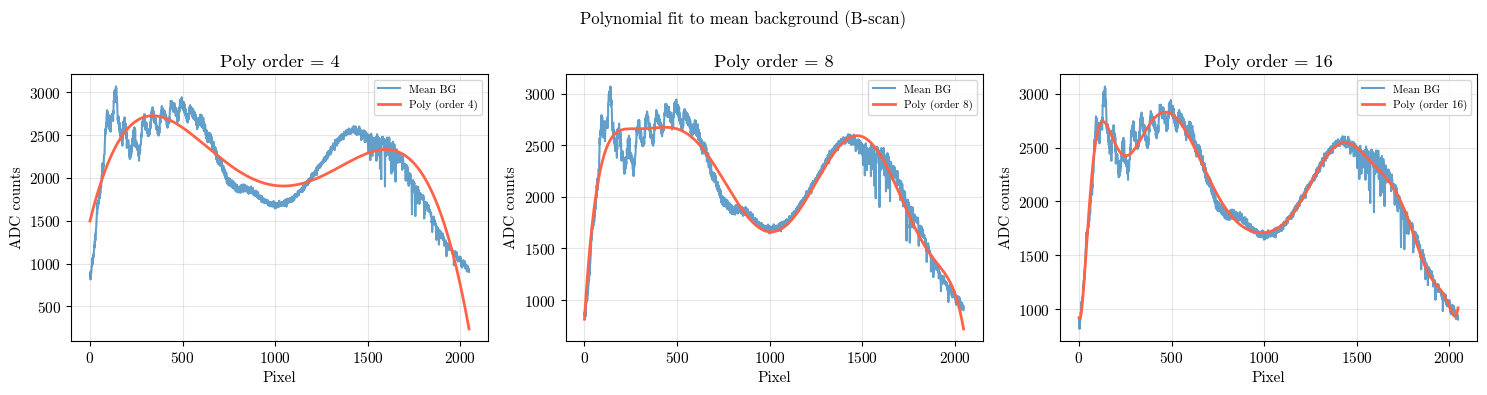

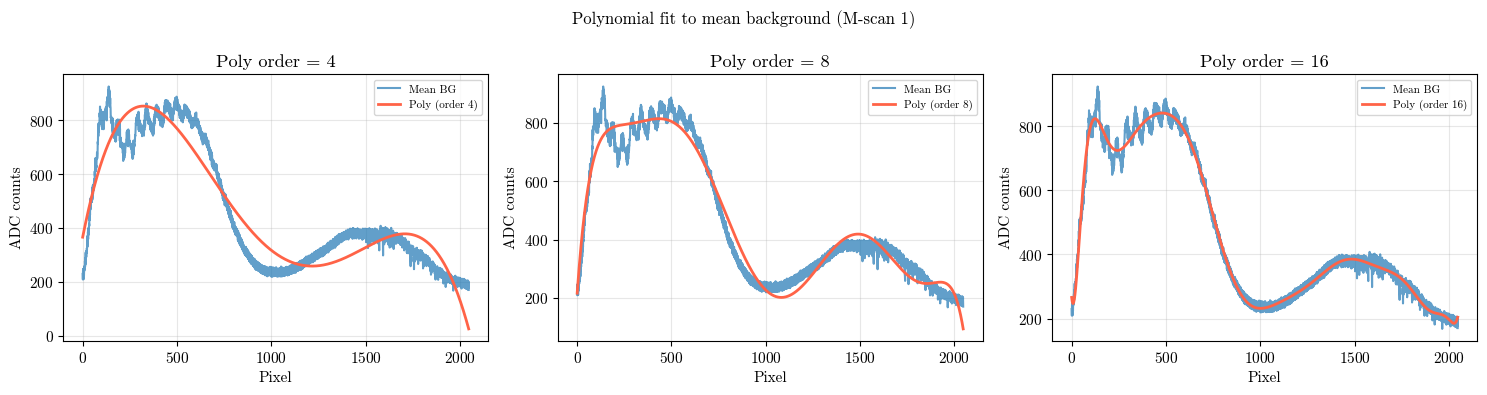

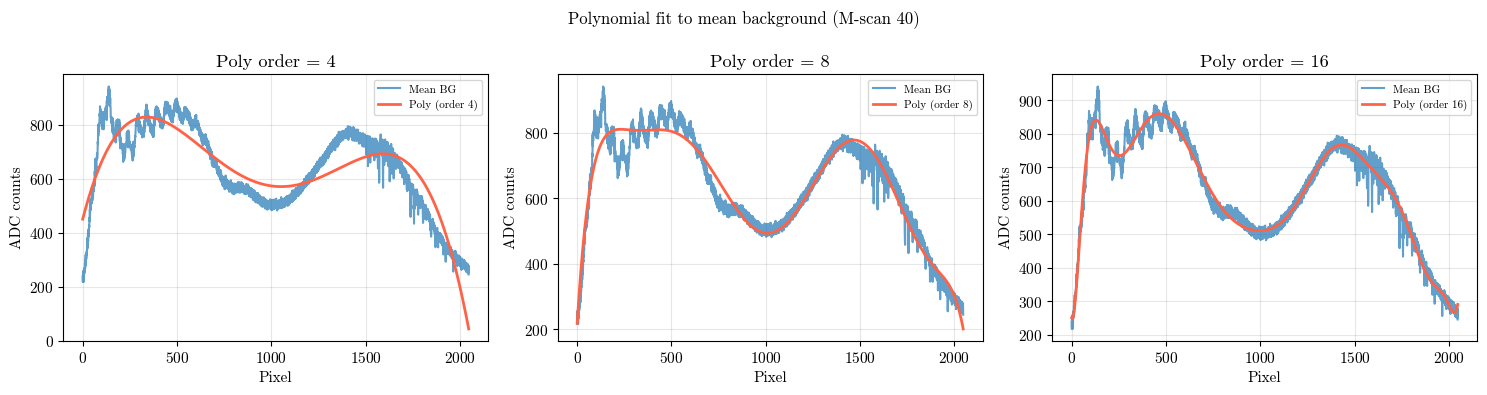

In [34]:
poly_order = [4, 8, 16]

fig2, axes2 = plt.subplots(1, len(poly_order), figsize=(15, 4))
for ax, order in zip(axes2, poly_order):
    coeffs   = np.polyfit(pixels, mean_bg_b.squeeze(), order)
    poly_func = np.polyval(coeffs, pixels)
    ax.plot(mean_bg_b.squeeze(), label="Mean BG", alpha=0.7)
    ax.plot(poly_func, label=f"Poly (order {order})", linewidth=2, color="tomato")
    ax.set_title(f"Poly order = {order}")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("ADC counts")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Polynomial fit to mean background (B-scan)", fontsize=12)
plt.tight_layout()
plt.savefig("Report/Results/poly_fit_comparison_bscan.png", dpi=150)
plt.show()

fig2, axes2 = plt.subplots(1, len(poly_order), figsize=(15, 4))
for ax, order in zip(axes2, poly_order):
    coeffs   = np.polyfit(pixels, mean_bg_m1.squeeze(), order)
    poly_func = np.polyval(coeffs, pixels)
    ax.plot(mean_bg_m1.squeeze(), label="Mean BG", alpha=0.7)
    ax.plot(poly_func, label=f"Poly (order {order})", linewidth=2, color="tomato")
    ax.set_title(f"Poly order = {order}")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("ADC counts")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Polynomial fit to mean background (M-scan 1)", fontsize=12)
plt.tight_layout()
plt.savefig("Report/Results/poly_fit_comparison_mscan_1.png", dpi=150)
plt.show()

fig2, axes2 = plt.subplots(1, len(poly_order), figsize=(15, 4))
for ax, order in zip(axes2, poly_order):
    coeffs   = np.polyfit(pixels, mean_bg_m40.squeeze(), order)
    poly_func = np.polyval(coeffs, pixels)
    ax.plot(mean_bg_m40.squeeze(), label="Mean BG", alpha=0.7)
    ax.plot(poly_func, label=f"Poly (order {order})", linewidth=2, color="tomato")
    ax.set_title(f"Poly order = {order}")
    ax.set_xlabel("Pixel")
    ax.set_ylabel("ADC counts")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Polynomial fit to mean background (M-scan 40)", fontsize=12)
plt.tight_layout()
plt.savefig("Report/Results/poly_fit_comparison_mscan_40.png", dpi=150)
plt.show()

tested_order = 16

## Run the pipeline

### Load and process scans

In [9]:
# Load L2K matrix
print("Loading L2K matrix...")
L2K = load_L2K(L2K_path)
assert L2K.shape == (N, N), f"Expected (2048,2048), got {L2K.shape}"

# Full pipeline A scans
print("\n=== Full pipeline ===")

print("\n[BScan_Layers.raw]")
ascans_bscan, t_bscan = compute_ascans(
    B_scan_path, N_BG_BSCAN, L2K, poly_order = tested_order
)

print("\n[MScan1.raw]")
ascans_ms1, t_ms1 = compute_ascans(
    M_scan_1_path, N_BG_MSCAN, L2K, poly_order = tested_order
)

print("\n[MScan40.raw]")
ascans_ms40, t_ms40 = compute_ascans(
    M_scan_40_path, N_BG_MSCAN, L2K, poly_order = tested_order
)

Loading L2K matrix...
  L2K loaded from key 'L2K', shape (2048, 2048)

=== Full pipeline ===

[BScan_Layers.raw]

───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw
───────────────────────────────────────────────────────
    Load                  : 0.0374 s
    → 10000 data A-scans, 175 backgrounds
    Average background    : 0.0004 s
    BG subtraction        : 0.0533 s
    Poly fit (order 16)   : 0.0013 s
    Hanning windowing     : 0.0742 s
    Deconvolution         : 0.0516 s
    L2K resampling        : 0.5547 s
    FFT                   : 0.3942 s
    ────────────────────────────────────
    TOTAL                 : 1.167 s


[MScan1.raw]

───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/MScan1.raw
───────────────────────────────────────────────────────
    Load                  : 0.378

### Plot 2 A-scans from the BScan file, as well as 1 A-scan from each M-scan file.

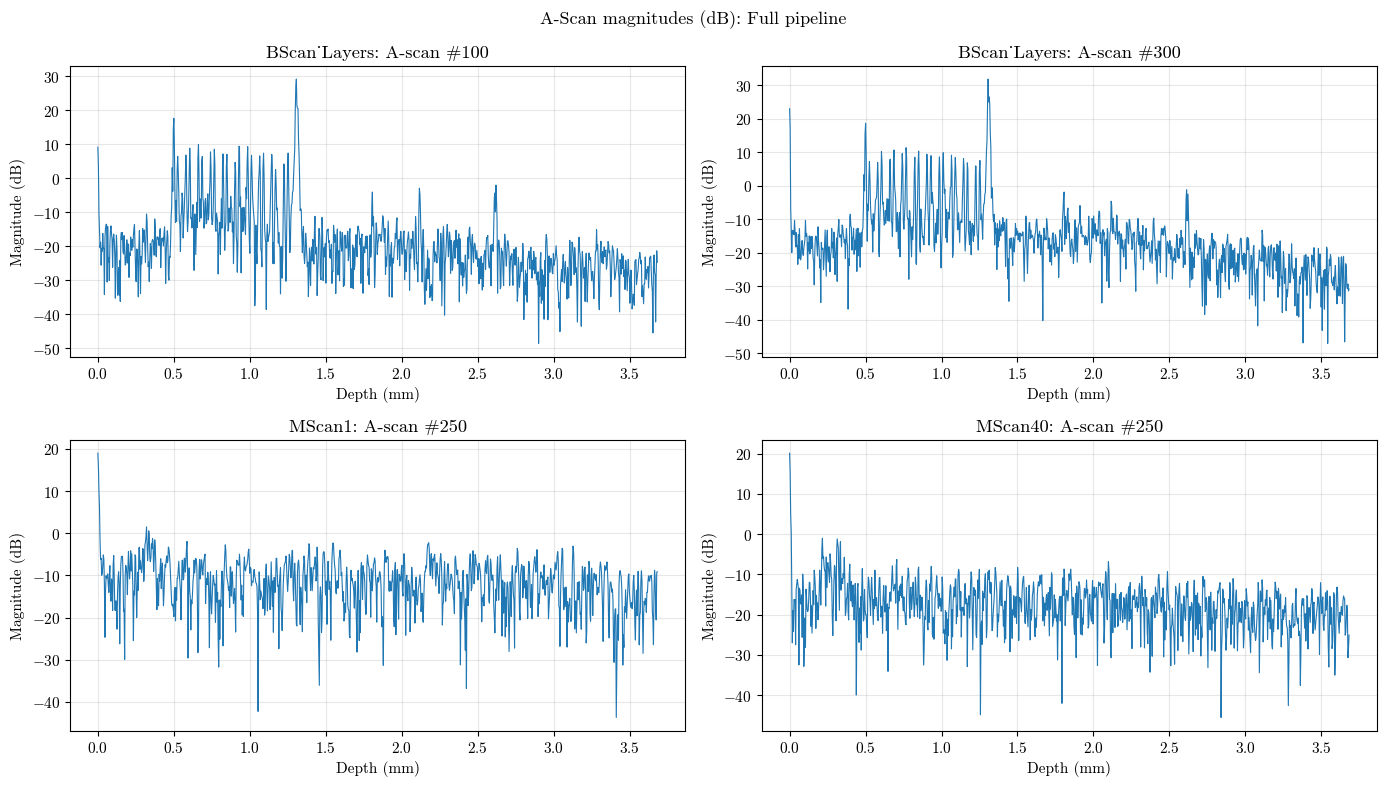

In [10]:
fig1, axes = plt.subplots(2, 2, figsize=(14, 8))
datasets = [
    (ascans_bscan, 100, "BScan_Layers: A-scan #100"),
    (ascans_bscan, 300, "BScan_Layers: A-scan #300"),
    (ascans_ms1,   250,  "MScan1: A-scan #250"),
    (ascans_ms40,  250,  "MScan40: A-scan #250"),
]
for ax, (asc, col, title) in zip(axes.flatten(), datasets):
    z, m = ascan_db(asc[:, col])
    ax.plot(z, m, linewidth=0.8)
    ax.set_xlabel("Depth (mm)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("A-Scan magnitudes (dB): Full pipeline", fontsize=13)
plt.tight_layout()
plt.savefig("Report/Results/ascans_full_pipeline.png", dpi=150)
plt.show()

### Pipeline comparison on one 'nice' A-scan from any file


=== Pipeline comparison variants ===

[No deconv, with BG sub]

───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw
───────────────────────────────────────────────────────
    Load                  : 0.0739 s
    → 10000 data A-scans, 175 backgrounds
    Average background    : 0.0017 s
    BG subtraction        : 0.0452 s
    Poly fit (order 8)    : 0.0014 s
    Hanning windowing     : 0.0312 s
    Deconvolution         : 0.0000 s
    L2K resampling        : 1.7697 s
    FFT                   : 0.3691 s
    ────────────────────────────────────
    TOTAL                 : 2.292 s


[No deconv, no BG sub]

───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw
───────────────────────────────────────────────────────
    Load                  : 0.0346 s
    → 10000 data A-scans, 175

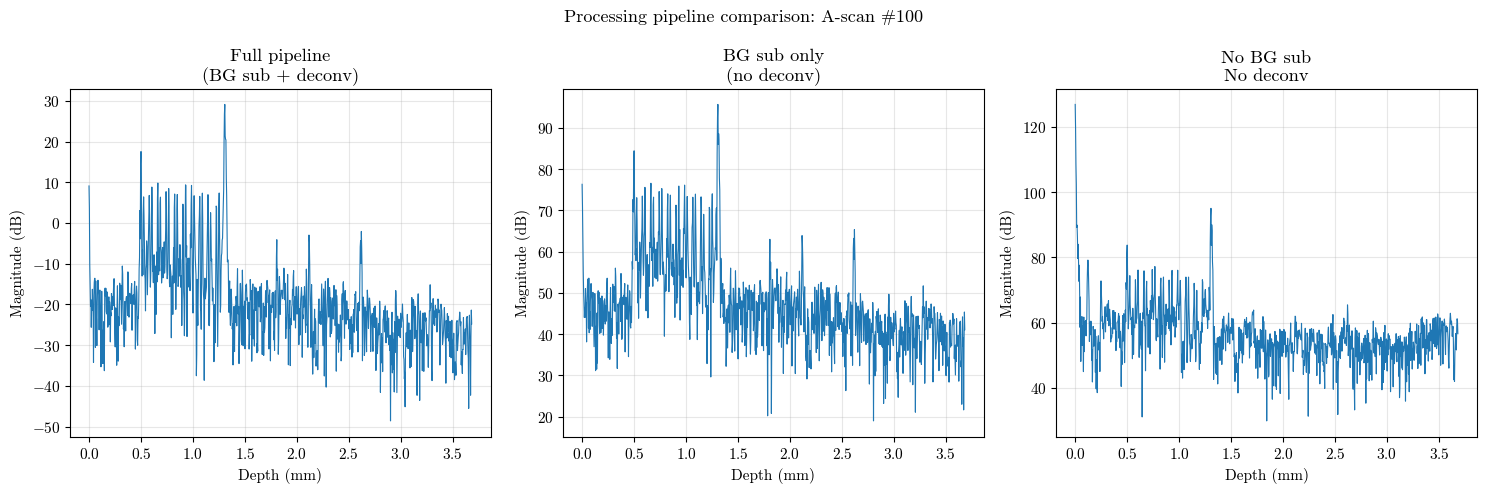


Done. Figures saved.


In [11]:
# Pipeline comparison on one 'nice' A-scan
NICE_COL = 100   # change after inspecting the B-scan to pick a clean column

print("\n=== Pipeline comparison variants ===")

print("\n[No deconv, with BG sub]")
ascans_no_deconv, _ = compute_ascans(
    B_scan_path, N_BG_BSCAN, L2K, do_deconv=False, do_background_sub=True
)

print("\n[No deconv, no BG sub]")
ascans_raw_only, _ = compute_ascans(
    B_scan_path, N_BG_BSCAN, L2K, do_deconv=False, do_background_sub=False
)

fig3 = plot_pipeline_comparison(
    ascans_bscan, ascans_no_deconv, ascans_raw_only, col=NICE_COL
)
plt.savefig("Report/Results/pipeline_comparison.png", dpi=150)
plt.show()

print("\nDone. Figures saved.")

# B-scans

## B-scan pipeline
Why a separate B-scan function?

If you called compute_ascans() in a loop (one call per column), you would
recompute mean_bg, poly_env, and the Hann window M times (once per A-scan)
even though they are identical for every column.  The B-scan function below
computes those shared quantities ONCE and applies them to all M columns in a
single set of operations.

Physical dimensions:

  Axial   : dz = 3.6 µm/pixel,  1024 pixels after mirror crop  → 3.69 mm deep

  Lateral : dx = 1 mm / M,      M pixels wide                  → 1 mm wide

In [11]:
def compute_bscan(
    filepath: str,
    n_bg: int,
    L2K: np.ndarray,
    poly_order: int = 16,
    do_deconv: bool = True,
    do_background_sub: bool = True,
    N: int = 2048,
    verbose: bool = True,
):
    """
    Process a raw B-scan file into a 2-D magnitude image (no for-loops).

    The key difference from calling compute_ascans() in a loop:
      - mean_bg, poly_env, and window are computed ONCE for all M columns.
      - All matrix ops are applied to the full (N, M) matrix simultaneously.

    Returns
    -------
    bscan_mag  : float ndarray, shape (N//2, M)  – magnitude (linear), mirror cropped
    ascans_cpx : complex ndarray, shape (N, M)   – full complex A-scans (for inspection)
    dx_mm      : lateral pixel size in mm
    """
    timings = {}

    def tick(label, t0):
        dt = time.perf_counter() - t0
        timings[label] = dt
        if verbose:
            print(f"    {label:<25s}: {dt:.4f} s")
        return time.perf_counter()

    if verbose:
        print(f"\n{'─'*55}\n  B-scan: {filepath}\n{'─'*55}")

    # Load
    t = time.perf_counter()
    bg, data = load_raw(filepath, n_bg, N)
    t = tick("Load", t)
    M = data.shape[1]
    dx_mm = bscan_width / M
    if verbose:
        print(f"    → M = {M} A-scans,  dx = {dx_mm*1000:.2f} µm/pixel")

    # Average background  (computed once for all M columns)
    mean_bg = bg.mean(axis=1, keepdims=True)          # (N, 1)
    t = tick("Average background", t)

    # Background subtraction
    if do_background_sub:
        data_bs = data - mean_bg                      # (N, M)
    else:
        data_bs = data.copy()
    t = tick("BG subtraction", t)

    # Polynomial fit to source spectrum  (computed only once)
    pixels   = np.arange(N, dtype=np.float64)
    coeffs   = np.polyfit(pixels, mean_bg.squeeze(), poly_order)
    poly_env = np.polyval(coeffs, pixels).reshape(-1, 1)   # (N, 1)
    t = tick(f"Poly fit (order {poly_order})", t)

    # Hann window  (computed once, applied to all M columns)
    window   = np.hanning(N).reshape(-1, 1)           # (N, 1)
    data_win = data_bs * window                        # (N, M)
    t = tick("Hann windowing", t)

    # Deconvolution
    if do_deconv:
        data_deconv = data_win / poly_env              # (N, M)
    else:
        data_deconv = data_win
    t = tick("Deconvolution", t)

    # Lambda to k resampling (L2K matrix multiply)
    data_k = L2K @ data_deconv                         # (N, M)
    t = tick("L2K resampling", t)

    # FFT to get A-scans
    ascans_cpx = np.fft.fft(data_k, axis=0)           # (N, M)
    t = tick("FFT", t)

    # Crop to positive-depth half (remove mirror image) 
    # The FFT of real-valued data is Hermitian symmetric: the second half
    # (indices N//2 .. N-1) is a mirror of the first half and carries no
    # new information.  Keep only indices 0 .. N//2-1.
    half      = N // 2
    bscan_mag = np.abs(ascans_cpx[:half, :])           # (1024, M)  linear magnitude
    t = tick("Mirror crop + magnitude", t)

    total = sum(timings.values())
    if verbose:
        print(f"    {'─'*36}")
        print(f"    {'TOTAL':<25s}: {total:.3f} s\n")

    return bscan_mag, ascans_cpx, dx_mm, timings


## Plotting functions

In [13]:
def bscan_extent(bscan_mag, dx_mm):
    """
    Return the matplotlib 'extent' argument [left, right, bottom, top] in mm
    so imshow uses true physical axes.
    """
    n_depth, M = bscan_mag.shape
    depth_mm   = n_depth * DZ_MM          # total depth in mm
    return [0, bscan_width, depth_mm, 0]   # origin at top-left (depth increases down)


def show_bscan(bscan_mag, dx_mm, title="B-Scan", cmap="gray",
               vmin_db=None, vmax_db=None, ax=None):
    """
    Display a B-scan magnitude image with correct physical aspect ratio.

    Images are shown in dB (20·log10) so faint layers are visible.
    Colormap range [vmin_db, vmax_db] clips the dynamic range for contrast.
    """
    bscan_db = 20 * np.log10(bscan_mag + 1e-12)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = ax.get_figure()

    extent = bscan_extent(bscan_mag, dx_mm)

    im = ax.imshow(
        bscan_db,
        cmap=cmap,
        aspect="equal",     # 1 mm/mm → physical distances correct on screen
        extent=extent,
        vmin=vmin_db,
        vmax=vmax_db,
        origin="upper",
    )
    ax.set_xlabel("Lateral position (mm)")
    ax.set_ylabel("Depth (mm)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Magnitude (dB)", fraction=0.03)
    return fig, ax


## Run the pipeline

### Load and process

In [14]:
# Load L2K matrix
print("Loading L2K matrix...")
L2K = load_L2K(L2K_path)
assert L2K.shape == (N, N), f"Expected (2048,2048), got {L2K.shape}"

bscan_full, ascans_cpx, dx_mm, _ = compute_bscan(
    B_scan_path, N_BG_BSCAN, L2K, poly_order=tested_order,
    do_deconv=True, do_background_sub=True,
)

# Print pixel sizes just to confirm
M = bscan_full.shape[1]
print(f"\nPixel sizes:")
print(f"  Axial   dz = {DZ_MM*1000:.1f} µm  ({N//2} pixels → {N//2 * DZ_MM:.2f} mm deep)")
print(f"  Lateral dx = {dx_mm*1000:.2f} µm  ({M} pixels → {bscan_width:.1f} mm wide)")
print(f"  Pixel aspect ratio dx/dz = {dx_mm/DZ_MM:.2f}")

Loading L2K matrix...
  L2K loaded from key 'L2K', shape (2048, 2048)

───────────────────────────────────────────────────────
  B-scan: /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw
───────────────────────────────────────────────────────
    Load                     : 0.0306 s
    → M = 10000 A-scans,  dx = 0.10 µm/pixel
    Average background       : 0.0003 s
    BG subtraction           : 0.0297 s
    Poly fit (order 16)      : 0.0007 s
    Hann windowing           : 0.0310 s
    Deconvolution            : 0.0309 s
    L2K resampling           : 0.6441 s
    FFT                      : 0.3383 s
    Mirror crop + magnitude  : 0.0175 s
    ────────────────────────────────────
    TOTAL                    : 1.123 s


Pixel sizes:
  Axial   dz = 3.6 µm  (1024 pixels → 3.69 mm deep)
  Lateral dx = 0.10 µm  (10000 pixels → 1.0 mm wide)
  Pixel aspect ratio dx/dz = 0.03


### Look at a few A-scans to choose contrast limits


  dB range: [-85.0, 40.4]
  1st–99th percentile: [-36.1, 14.5] dB  ← use these as vmin/vmax


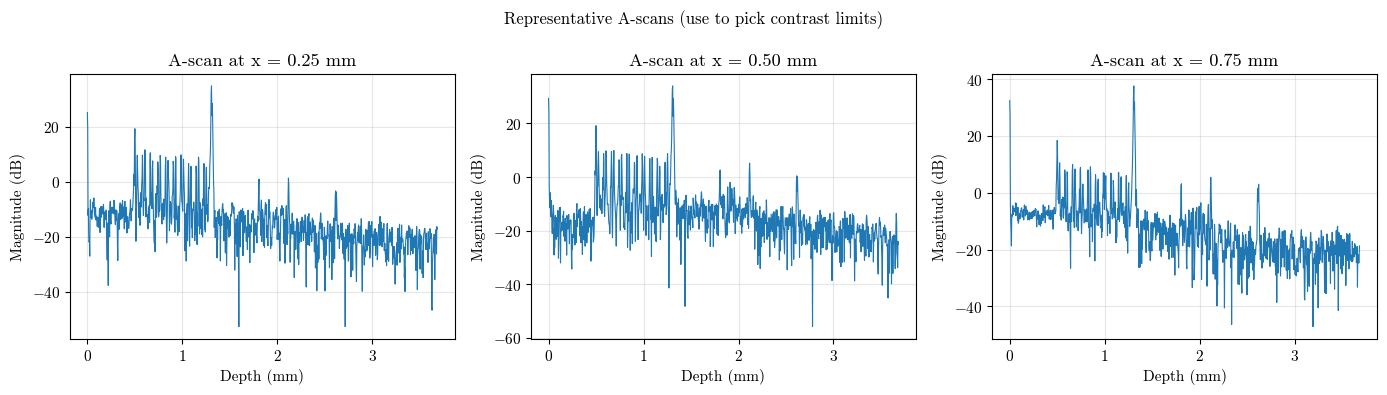

In [15]:
# Inspect the dB distribution to pick good vmin/vmax for imshow.
# A-scan peaks show where the tape layers are — use that range.
bscan_db_all = 20 * np.log10(bscan_full + 1e-12)
p1  = np.percentile(bscan_db_all, 1)
p10 = np.percentile(bscan_db_all, 10)
p99 = np.percentile(bscan_db_all, 99)
print(f"\n  dB range: [{bscan_db_all.min():.1f}, {bscan_db_all.max():.1f}]")
print(f"  1st–99th percentile: [{p1:.1f}, {p99:.1f}] dB  ← use these as vmin/vmax")

# Sample A-scans to find a good contrast window 
fig0, axes0 = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes0, [M//4, M//2, 3*M//4]):
    z_mm = np.arange(N//2) * DZ_MM
    mag  = 20 * np.log10(np.abs(ascans_cpx[:N//2, col]) + 1e-12)
    ax.plot(z_mm, mag, linewidth=0.8)
    ax.set_xlabel("Depth (mm)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"A-scan at x = {col*dx_mm:.2f} mm")
    ax.grid(True, alpha=0.3)
plt.suptitle("Representative A-scans (use to pick contrast limits)", fontsize=12)
plt.tight_layout()
plt.savefig("Report/Results/bscan_sample_ascans.png", dpi=150)
plt.show()

### Unprocessed vs processed B-scan side by side

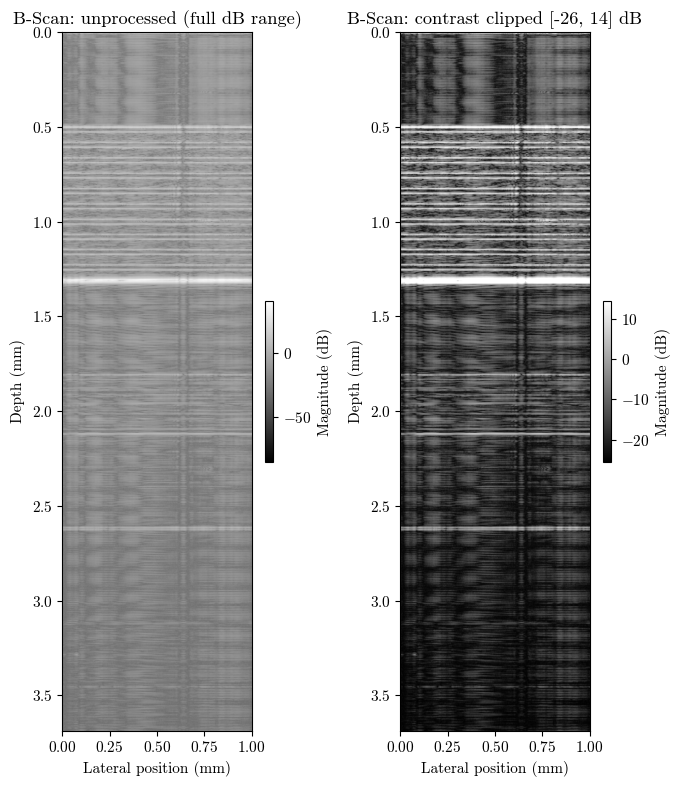

In [18]:
# "Unprocessed" here means: no contrast clipping — raw dB image.
# "Processed"   means: dB + contrast window tuned to the tape layer range.

# Adjust VMIN_DB / VMAX_DB after looking at the A-scan plots above.
# A good starting point: VMAX_DB = peak of a bright layer, VMIN_DB = VMAX-40.
VMAX_DB = p99          # start with 99th percentile
VMIN_DB = p10 # 40 dB dynamic range is typical for OCT display

fig1, axes1 = plt.subplots(1, 2, figsize=(7, 8))

show_bscan(bscan_full, dx_mm,
            title="B-Scan: unprocessed (full dB range)",
            vmin_db=bscan_db_all.min(), vmax_db=bscan_db_all.max(),
            ax=axes1[0])

show_bscan(bscan_full, dx_mm,
            title=f"B-Scan: contrast clipped [{VMIN_DB:.0f}, {VMAX_DB:.0f}] dB",
            vmin_db=VMIN_DB, vmax_db=VMAX_DB,
            ax=axes1[1])

# plt.suptitle("B-Scan: BScan_Layers.raw (full pipeline)", fontsize=13)
plt.tight_layout()
plt.savefig("Report/Results/bscan_full_pipeline.png", dpi=150)
plt.show()

### Comparison with vs without deconvolution

Computing B-scan without deconvolution...

───────────────────────────────────────────────────────
  B-scan: /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/Bscan_Layers.raw
───────────────────────────────────────────────────────
    Load                     : 0.0358 s
    → M = 10000 A-scans,  dx = 0.10 µm/pixel
    Average background       : 0.0002 s
    BG subtraction           : 0.0300 s
    Poly fit (order 16)      : 0.0007 s
    Hann windowing           : 0.0355 s
    Deconvolution            : 0.0000 s
    L2K resampling           : 0.7755 s
    FFT                      : 0.3332 s
    Mirror crop + magnitude  : 0.0172 s
    ────────────────────────────────────
    TOTAL                    : 1.228 s



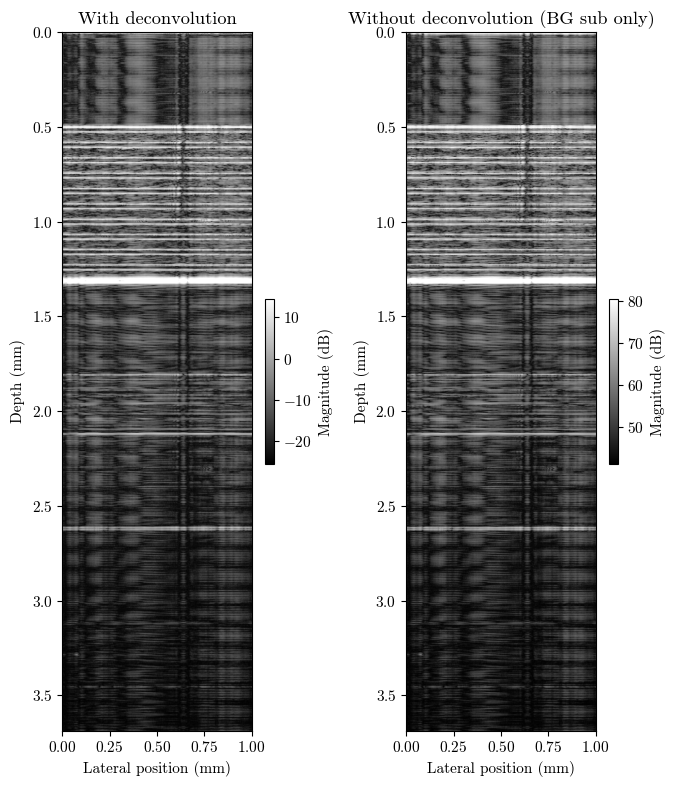

All B-scan figures saved.


In [19]:
print("Computing B-scan without deconvolution...")
bscan_no_deconv, _, _, _ = compute_bscan(
    B_scan_path, N_BG_BSCAN, L2K, poly_order=tested_order,
    do_deconv=False, do_background_sub=True,
)

# Compute contrast limits for the no-deconv B-scan separately
# (deconvolution divides by poly_env ~thousands of ADC counts, so
#  the two B-scans live in very different dB ranges)
bscan_nd_db = 20 * np.log10(bscan_no_deconv + 1e-12)
vmin_nd = np.percentile(bscan_nd_db, 10)
vmax_nd = np.percentile(bscan_nd_db, 99)

fig2, axes2 = plt.subplots(1, 2, figsize=(7, 8))

show_bscan(bscan_full, dx_mm,
            title="With deconvolution",
            vmin_db=VMIN_DB, vmax_db=VMAX_DB, ax=axes2[0])

show_bscan(bscan_no_deconv, dx_mm,
            title="Without deconvolution (BG sub only)",
            vmin_db=vmin_nd, vmax_db=vmax_nd, ax=axes2[1])

# plt.suptitle("Effect of deconvolution on B-Scan", fontsize=13)
plt.tight_layout()
plt.savefig("Report/Results/bscan_deconv_comparison.png", dpi=150)
plt.show()

print("All B-scan figures saved.")

# M-Scans

## SDPM Function

In [24]:
"""
  1. Compute complex A-scans for the full M-scan (same pipeline as before)
  2. Average the magnitude over time → find the speaker membrane pixel indices
  3. For each pixel of interest:
       a. Extract the phase time-series  φ(t) = angle(A(z0, t))
       b. Unwrap φ(t)  (remove 2π jumps)
       c. Convert to displacement in nm
  4. Display in time domain and frequency domain
"""

def sdpm(
    ascans_cpx: np.ndarray,
    pixel_idx: int,
    fs: float = FS,
    lam0_nm: float = lambda_0,
    n: float = n,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Extract sub-pixel displacement from a time-series of complex A-scans.
 
    Parameters
    ----------
    ascans_cpx : complex ndarray (N, R)  – complex A-scans over time
    pixel_idx  : depth index (row) of the reflector to track
    fs         : A-scan sampling rate (Hz)
    lam0_nm    : source centre wavelength (nm)
    n          : refractive index of medium
 
    Returns
    -------
    t_s   : time axis (seconds), length R
    d_nm  : displacement time series (nm), length R
    freqs : frequency axis (Hz) for one-sided spectrum, length R//2
    D_nm  : one-sided magnitude spectrum (nm), length R//2
    """
    R = ascans_cpx.shape[1]
 
    # Extract phase at this depth pixel across all time steps
    phase_raw = np.angle(ascans_cpx[pixel_idx, :])        # (R,)
 
    # Unwrap: remove 2π discontinuities so phase is continuous
    phase_unwrapped = np.unwrap(phase_raw)                 # (R,)
 
    # Convert phase to displacement (nm):  d = φ · λ0 / (4π·n)
    d_nm = phase_unwrapped * lam0_nm / (4 * np.pi * n)
 
    # Remove DC offset
    # d_nm -= d_nm.mean()
    
    # Skip first few transient samples
    # In sdpm, after computing d_nm, replace the skip/detrend with:
    skip = 100
    d_nm = d_nm[skip:]
    d_nm = scipy.signal.detrend(d_nm, type='linear')
    t_s = np.arange(len(d_nm)) / fs
 
    # One-sided FFT magnitude spectrum
    R = len(d_nm)
    D = np.fft.fft(d_nm)
    freqs_full = np.fft.fftfreq(R, d=1 / fs)
    half = R // 2
    freqs = freqs_full[:half]
    D_nm = (2.0 / R) * np.abs(D[:half])
 
    return t_s, d_nm, freqs, D_nm

## Plotting functions

In [20]:
def plot_sdpm(t_s, d_nm, freqs, D_nm, pixel_idx, label=""):
    """Time-domain and frequency-domain displacement plots for one pixel."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))
 
    ax1.plot(t_s * 1e3, d_nm, linewidth=0.6)
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Displacement (nm)")
    ax1.set_title(f"SDPM time domain: pixel {pixel_idx}  {label}")
    ax1.grid(True, alpha=0.3)
 
    ax2.plot(freqs / 1e3, D_nm, linewidth=0.8)
    ax2.set_xlabel("Frequency (kHz)")
    ax2.set_ylabel("|Displacement| (nm)")
    ax2.set_title(f"SDPM frequency domain: pixel {pixel_idx}  {label}")
    ax2.grid(True, alpha=0.3)
 
    plt.tight_layout()
    return fig
 
 
def plot_avg_magnitude(ascans_cpx, label=""):
    """
    Plot the time-averaged A-scan magnitude (dB) to locate the speaker membrane.
    """
    half    = N // 2
    avg_mag = np.abs(ascans_cpx[:half, :]).mean(axis=1)
    avg_db  = 20 * np.log10(avg_mag + 1e-12)
    z_mm    = np.arange(half) * DZ_MM
 
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(z_mm, avg_db, linewidth=0.8)
    ax.set_xlabel("Depth (mm)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(f"Time-averaged A-scan magnitude: {label}\n"
                 "(find high-intensity band = speaker membrane)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
 
    return fig, avg_mag, z_mm
 
 
def find_membrane_pixels(avg_mag, z_mm, z_center_mm=None, window_mm=1.0,
                         distance=10, n_peaks=2):
    """
    Find the n_peaks most prominent peaks in the averaged A-scan magnitude,
    optionally restricted to a depth window around z_center_mm.
 
    Uses scipy.signal.find_peaks with a minimum distance so we don't pick
    two adjacent bins on the same reflection.
    """
    region = avg_mag.copy()
    if z_center_mm is not None:
        mask = np.abs(z_mm - z_center_mm) < window_mm
        region[~mask] = 0
 
    peaks, properties = scipy.signal.find_peaks(region, distance=distance)
 
    if len(peaks) == 0:
        raise ValueError("No peaks found – adjust z_center_mm or window_mm")
 
    # Sort by magnitude descending, keep top n_peaks
    order = np.argsort(avg_mag[peaks])[::-1]
    top   = peaks[order[:n_peaks]]
    return sorted(top)
 
 
# def identify_tones(freqs, D_nm, n_tones, min_prominence=None):
#     """
#     Return the frequencies (kHz) and amplitudes of the n_tones most prominent
#     spectral peaks.  Uses scipy.signal.find_peaks with prominence filtering
#     so we pick real tones instead of noise / leakage bins.
 
#     If min_prominence is None, a sensible default of 5% of the max spectral
#     amplitude is used.
#     """
#     if min_prominence is None:
#         min_prominence = 0.05 * D_nm.max()
 
#     peaks, props = scipy.signal.find_peaks(D_nm, prominence=min_prominence)
 
#     if len(peaks) == 0:
#         # Fall back: just take the n_tones largest bins
#         peaks = np.argpartition(D_nm, -n_tones)[-n_tones:]
 
#     # Sort by amplitude descending, keep top n_tones
#     order      = np.argsort(D_nm[peaks])[::-1]
#     top_peaks  = peaks[order[:n_tones]]
 
#     peak_freqs = freqs[top_peaks] / 1e3   # kHz
#     peak_amps  = D_nm[top_peaks]
 
#     # Return sorted by frequency
#     sort_idx   = np.argsort(peak_freqs)
#     return peak_freqs[sort_idx], peak_amps[sort_idx]

def identify_tones(freqs, D_nm, n_tones, min_prominence=None, min_freq_hz=500):
    """Skip DC and low-freq artifacts below min_freq_hz."""
    if min_prominence is None:
        min_prominence = 0.05 * D_nm.max()

    # Mask out frequencies below threshold
    valid = freqs > min_freq_hz
    D_masked = D_nm.copy()
    D_masked[~valid] = 0

    peaks, props = scipy.signal.find_peaks(D_masked, prominence=min_prominence)

    if len(peaks) == 0:
        peaks = np.argpartition(D_masked, -n_tones)[-n_tones:]

    order     = np.argsort(D_nm[peaks])[::-1]
    top_peaks = peaks[order[:n_tones]]

    peak_freqs = freqs[top_peaks] / 1e3
    peak_amps  = D_nm[top_peaks]

    sort_idx = np.argsort(peak_freqs)
    return peak_freqs[sort_idx], peak_amps[sort_idx]
 

## Run the pipeline

### Process MScan 1

In [22]:
# Load L2K matrix
print("Loading L2K matrix...")
L2K = load_L2K(L2K_path)
assert L2K.shape == (N, N), f"Expected (2048,2048), got {L2K.shape}"

print("\n=== MScan1 ===")
ascans_ms1, _ = compute_ascans(
    M_scan_1_path, N_BG_MSCAN, L2K, poly_order=tested_order, verbose=True
)

Loading L2K matrix...
  L2K loaded from key 'L2K', shape (2048, 2048)

=== MScan1 ===

───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/MScan1.raw
───────────────────────────────────────────────────────
    Load                  : 0.7160 s
    → 104448 data A-scans, 320 backgrounds
    Average background    : 0.0010 s
    BG subtraction        : 0.9356 s
    Poly fit (order 16)   : 0.0303 s
    Hanning windowing     : 1.0734 s
    Deconvolution         : 1.1498 s
    L2K resampling        : 6.2593 s
    FFT                   : 4.9062 s
    ────────────────────────────────────
    TOTAL                 : 15.072 s




  Membrane pixels: A=60 (0.216 mm), B=93 (0.335 mm)


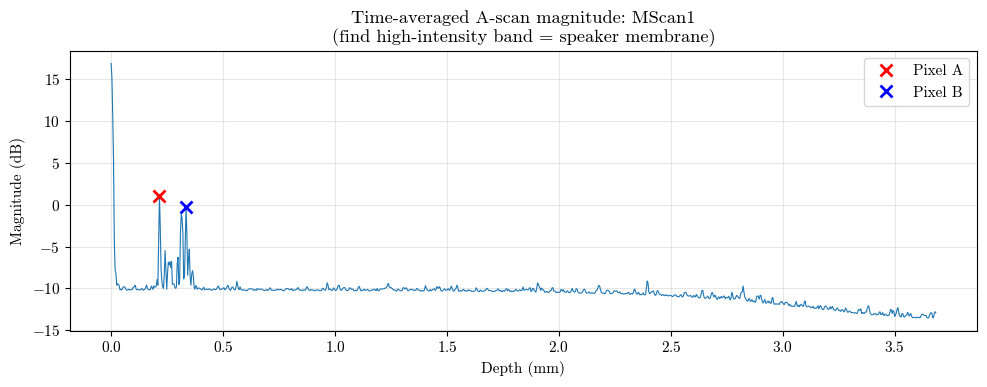


  Running SDPM on pixel 60...
  Running SDPM on pixel 93...

  MScan1 dominant tone (pixel A): 8.011 kHz  amplitude = 5.83 nm
  MScan1 dominant tone (pixel B): 8.011 kHz  amplitude = 5.90 nm


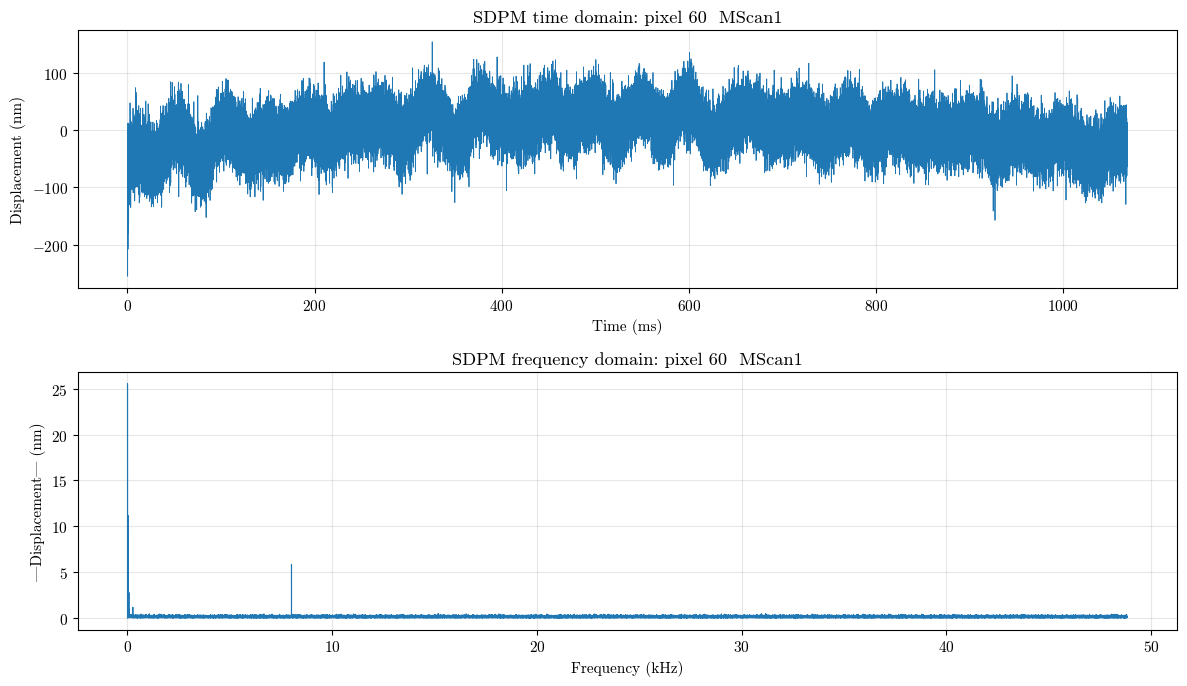

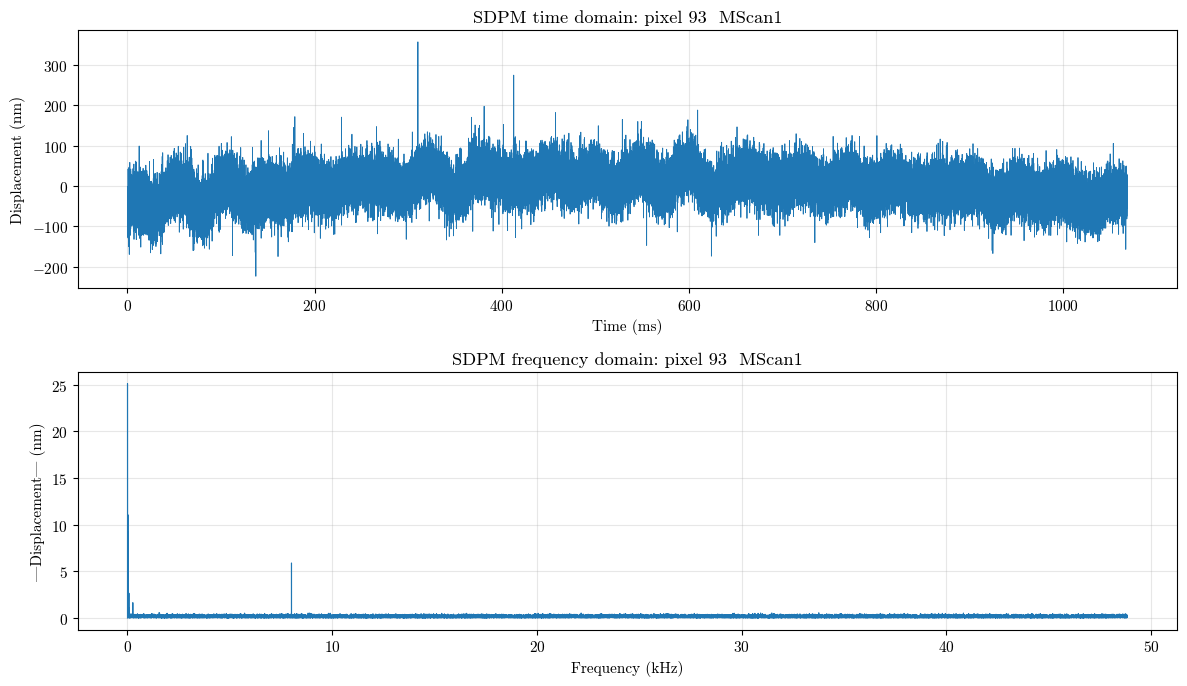

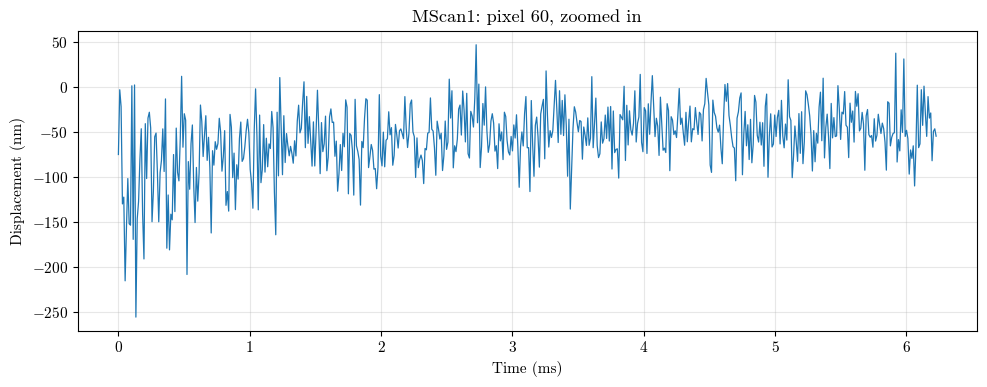

In [ ]:
# # ── Average magnitude → find speaker membrane ────────────────────────────
# fig_avg1, avg_mag1, z_mm = plot_avg_magnitude(ascans_ms1, label="MScan1")
# plt.savefig("Report/Results/mscan1_avg_magnitude.png", dpi=150)
# plt.show()
 
# # ── Locate membrane pixels using proper peak-finding ─────────────────────
# # Set Z_SPEAKER_MM to roughly where you see the bright band, or set to None
# # to search the full depth range.
# Z_SPEAKER_MM = 0.25  # None = search full range; set e.g. 0.25 to restrict
 
# membrane_pixels_ms1 = find_membrane_pixels(
#     avg_mag1, z_mm,
#     z_center_mm=Z_SPEAKER_MM,
#     window_mm=1.0,
#     distance=10,
#     n_peaks=2,
# )
# PIXEL_A_MS1, PIXEL_B_MS1 = membrane_pixels_ms1[0], membrane_pixels_ms1[-1]

# print(f"\n  Membrane pixels: A={PIXEL_A_MS1} ({z_mm[PIXEL_A_MS1]:.3f} mm), "
#       f"B={PIXEL_B_MS1} ({z_mm[PIXEL_B_MS1]:.3f} mm)")
 
# # ── SDPM on both pixels ─────────────────────────────────────────────────
# print(f"\n  Running SDPM on pixel {PIXEL_A_MS1}...")
# t1, d1_a, f1, D1_a = sdpm(ascans_ms1, PIXEL_A_MS1)
 
# print(f"  Running SDPM on pixel {PIXEL_B_MS1}...")
# t1, d1_b, f1, D1_b = sdpm(ascans_ms1, PIXEL_B_MS1)

# ── Average magnitude → find speaker membrane ────────────────────────────
fig_avg1, avg_mag1, z_mm = plot_avg_magnitude(ascans_ms1, label="MScan1")
 
# ── Locate membrane pixels using proper peak-finding ─────────────────────
# Set Z_SPEAKER_MM to roughly where you see the bright band, or set to None
# to search the full depth range.
Z_SPEAKER_MM = 0.25  # None = search full range; set e.g. 0.25 to restrict
 
membrane_pixels_ms1 = find_membrane_pixels(
    avg_mag1, z_mm,
    z_center_mm=Z_SPEAKER_MM,
    window_mm=1.0,
    distance=10,
    n_peaks=2,
)
PIXEL_A_MS1, PIXEL_B_MS1 = membrane_pixels_ms1[0], membrane_pixels_ms1[-1]

print(f"\n  Membrane pixels: A={PIXEL_A_MS1} ({z_mm[PIXEL_A_MS1]:.3f} mm), "
      f"B={PIXEL_B_MS1} ({z_mm[PIXEL_B_MS1]:.3f} mm)")

# ---> ADD MARKERS HERE <---
# Grab the axis from the figure we created earlier
ax = fig_avg1.gca()

# Calculate the dB values for the markers (to match the plot's y-axis)
mag_db_A = 20 * np.log10(avg_mag1[PIXEL_A_MS1] + 1e-12)
mag_db_B = 20 * np.log10(avg_mag1[PIXEL_B_MS1] + 1e-12)

# Plot the markers (e.g., a red 'x' and a blue 'x')
ax.plot(z_mm[PIXEL_A_MS1], mag_db_A, 'rx', markersize=8, markeredgewidth=2, label=f'Pixel A')
ax.plot(z_mm[PIXEL_B_MS1], mag_db_B, 'bx', markersize=8, markeredgewidth=2, label=f'Pixel B')
ax.legend()

# NOW save and show the plot with the markers included
fig_avg1.savefig("Report/Results/mscan1_avg_magnitude.png", dpi=150)
import matplotlib.pyplot as plt
plt.show()

 
# ── SDPM on both pixels ─────────────────────────────────────────────────
print(f"\n  Running SDPM on pixel {PIXEL_A_MS1}...")
t1, d1_a, f1, D1_a = sdpm(ascans_ms1, PIXEL_A_MS1)
 
print(f"  Running SDPM on pixel {PIXEL_B_MS1}...")
t1, d1_b, f1, D1_b = sdpm(ascans_ms1, PIXEL_B_MS1)
 
# ── Identify the tone ───────────────────────────────────────────────────
tone_freqs_a, tone_amps_a = identify_tones(f1, D1_a, n_tones=1)
tone_freqs_b, tone_amps_b = identify_tones(f1, D1_b, n_tones=1)
print(f"\n  MScan1 dominant tone (pixel A): {tone_freqs_a[0]:.3f} kHz  "
      f"amplitude = {tone_amps_a[0]:.2f} nm")
print(f"  MScan1 dominant tone (pixel B): {tone_freqs_b[0]:.3f} kHz  "
      f"amplitude = {tone_amps_b[0]:.2f} nm")
 
# ── Plots ────────────────────────────────────────────────────────────────
fig1a = plot_sdpm(t1, d1_a, f1, D1_a, PIXEL_A_MS1, label="MScan1")
plt.savefig("Report/Results/mscan1_sdpm_pixelA.png", dpi=150)
plt.show()
 
fig1b = plot_sdpm(t1, d1_b, f1, D1_b, PIXEL_B_MS1, label="MScan1")
plt.savefig("Report/Results/mscan1_sdpm_pixelB.png", dpi=150)
plt.show()
 
# ── Zoom into time domain───────────────────────────────────
fig_zoom, ax_zoom = plt.subplots(figsize=(10, 4))
n_show = int(50 * FS / (tone_freqs_a[0] * 1e3))   # 5 cycles
ax_zoom.plot(t1[:n_show] * 1e3, d1_a[:n_show], linewidth=0.9)
ax_zoom.set_xlabel("Time (ms)")
ax_zoom.set_ylabel("Displacement (nm)")
ax_zoom.set_title(f"MScan1: pixel {PIXEL_A_MS1}, zoomed in")
ax_zoom.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Report/Results/mscan1_zoom.png", dpi=150)
plt.show()

### Process MScan 40

In [ ]:
# Process MScan40
ascans_ms40, _ = compute_ascans(
    M_scan_40_path, N_BG_MSCAN, L2K, poly_order=tested_order, verbose=True
)

# Average magnitude for membrane detection — use only the positive half
half = N // 2
avg_mag40 = np.abs(ascans_ms40[:half, :]).mean(axis=1)
z_mm_40 = np.arange(half) * DZ_MM

# ── Average magnitude → find speaker membrane ────────────────────────────
fig_avg40, avg_mag40, z_mm_40 = plot_avg_magnitude(ascans_ms40, label="MScan40")
plt.savefig("Report/Results/mscan40_avg_magnitude.png", dpi=150)
plt.show()
 

# Extract ONLY the rows you need, then free the giant array
membrane_pixels_ms40 = find_membrane_pixels(
    avg_mag40, z_mm_40,
    z_center_mm=None,
    window_mm=1.0,
    distance=10,
    n_peaks=2,
)
PIXEL_A_MS40, PIXEL_B_MS40 = membrane_pixels_ms40[0], membrane_pixels_ms40[-1]

row_a = ascans_ms40[PIXEL_A_MS40, :].copy()
row_b = ascans_ms40[PIXEL_B_MS40, :].copy()
del ascans_ms40
import gc; gc.collect()

# Then pass 1D rows to sdpm — reshape to (1, R) so indexing still works
t40, d40_a, f40, D40_a = sdpm(row_a.reshape(1, -1), 0)
t40, d40_b, f40, D40_b = sdpm(row_b.reshape(1, -1), 0)



# print("\n=== MScan40 ===")
# ascans_ms40, _ = compute_ascans(
#     M_scan_40_path, N_BG_MSCAN, L2K, poly_order=tested_order, verbose=True
# )
 
# # ── Average magnitude → re-detect membrane pixels for MScan40 ───────────
# fig_avg40, avg_mag40, z_mm_40 = plot_avg_magnitude(ascans_ms40, label="MScan40")
# plt.savefig("Report/Results/mscan40_avg_magnitude.png", dpi=150)
# plt.show()
 
# membrane_pixels_ms40 = find_membrane_pixels(
#     avg_mag40, z_mm_40,
#     z_center_mm=Z_SPEAKER_MM,
#     window_mm=1.0,
#     distance=10,
#     n_peaks=2,
# )
# PIXEL_A_MS40, PIXEL_B_MS40 = membrane_pixels_ms40[0], membrane_pixels_ms40[-1]
# print(f"\n  Membrane pixels: A={PIXEL_A_MS40} ({z_mm_40[PIXEL_A_MS40]:.3f} mm), "
#       f"B={PIXEL_B_MS40} ({z_mm_40[PIXEL_B_MS40]:.3f} mm)")
 
# # ── SDPM ─────────────────────────────────────────────────────────────────
# t40, d40_a, f40, D40_a = sdpm(ascans_ms40, PIXEL_A_MS40)
# t40, d40_b, f40, D40_b = sdpm(ascans_ms40, PIXEL_B_MS40)
 
# ── Identify the 40 tones (with prominence-based peak finding) ──────────
tone_freqs_40, tone_amps_40 = identify_tones(f40, D40_a, n_tones=40)
print(f"\n  MScan40 – {len(tone_freqs_40)} identified tones (kHz):")
for i, (fr, amp) in enumerate(zip(tone_freqs_40, tone_amps_40)):
    print(f"    {i+1:2d}.  {fr:.3f} kHz   ({amp:.2f} nm)")
 
# ── Plots ────────────────────────────────────────────────────────────────
fig40a = plot_sdpm(t40, d40_a, f40, D40_a, PIXEL_A_MS40, label="MScan40")
plt.savefig("Report/Results/mscan40_sdpm_pixelA.png", dpi=150)
plt.show()
 
fig40b = plot_sdpm(t40, d40_b, f40, D40_b, PIXEL_B_MS40, label="MScan40")
plt.savefig("Report/Results/mscan40_sdpm_pixelB.png", dpi=150)
plt.show()
 


───────────────────────────────────────────────────────
  File : /Users/sophiaklymchuk/Python-Cooper-Union/ECE-435 Medical Imaging/Project-2/MScan40.raw
───────────────────────────────────────────────────────
    Load                  : 0.3080 s
    → 106496 data A-scans, 320 backgrounds
    Average background    : 0.0003 s
    BG subtraction        : 0.2233 s
    Poly fit (order 16)   : 0.0009 s
    Hanning windowing     : 1.0641 s
    Deconvolution         : 1.5034 s
    L2K resampling        : 6.9824 s


### Amplitude comparison between pixels and between SPLs

In [ ]:
print("\n=== Amplitude comparison ===")
print(f"  MScan1  pixel A:  {tone_amps_a[0]:.2f} nm  @ {tone_freqs_a[0]:.3f} kHz")
print(f"  MScan1  pixel B:  {tone_amps_b[0]:.2f} nm  @ {tone_freqs_b[0]:.3f} kHz")
 
# Find the MScan1 tone frequency in MScan40's spectrum for linearity check
ms1_freq_khz = tone_freqs_a[0]
idx_in_40    = np.argmin(np.abs(f40 / 1e3 - ms1_freq_khz))
amp_at_ms1_freq_in_40 = D40_a[idx_in_40]
print(f"\n  Amplitude at {ms1_freq_khz:.3f} kHz in MScan40: "
      f"{amp_at_ms1_freq_in_40:.2f} nm")
print(f"  (Compare to MScan1 amplitude = {tone_amps_a[0]:.2f} nm)")
print(f"  Both at 80 dB SPL → amplitude ratio should be ~1 if linear")
print(f"  Observed ratio = {amp_at_ms1_freq_in_40 / (tone_amps_a[0] + 1e-12):.3f}")
 
# Check if speaker is all-pass by looking at amplitude variation across 40 tones
if len(tone_amps_40) > 1:
    print(f"\n  MScan40 amplitude range: {tone_amps_40.min():.2f} – {tone_amps_40.max():.2f} nm")
    print(f"  Ratio max/min = {tone_amps_40.max() / (tone_amps_40.min() + 1e-12):.1f}x")
    print(f"  (If speaker were all-pass, all 40 tones would have equal amplitude)")
 
print("\nDone.")


=== Amplitude comparison ===
  MScan1  pixel A:  5.83 nm  @ 8.011 kHz
  MScan1  pixel B:  5.90 nm  @ 8.011 kHz

  Amplitude at 8.011 kHz in MScan40: 0.07 nm
  (Compare to MScan1 amplitude = 5.83 nm)
  Both at 80 dB SPL → amplitude ratio should be ~1 if linear
  Observed ratio = 0.013

  MScan40 amplitude range: 2.76 – 47.93 nm
  Ratio max/min = 17.4x
  (If speaker were all-pass, all 40 tones would have equal amplitude)

Done.
